# Setting up a basic ReAct Agent in LangGraph

In [1]:
from dotenv import load_dotenv

load_dotenv()  # https://serpapi.com for a free token to google things!

True

In [2]:
# Load tools for the ReAct agent
# load_tools is a utility function that loads and initializes LangChain tools
# The "serpapi" tool enables the agent to perform web searches via SerpAPI
# This is essential for the ReAct agent to gather real-time information from the web
from langchain_community.agent_toolkits.load_tools import load_tools
tools = load_tools(["serpapi"])


In [3]:
# Display the loaded tools to verify what tools are available for the ReAct agent
# This will show the tool name, description, and function details
print(tools[0].name)
print(tools[0].description)

Search
A search engine. Useful for when you need to answer questions about current events. Input should be a search query.


In [4]:
tools[0].run('Sinan Ozdemir')

'[\'Ozdemir Sinan : Sinan is an active lecturer focusing on large language models and a former lecturer of data science at the Johns Hopkins University. He is the author of multiple textbooks on data science and machine learning including "Quick Start Guide to LLMs". ...\', \'Sinan Ozdemir type: Author.\', \'Sinan Ozdemir entity_type: people.\', \'Sinan Ozdemir kgmid: /g/11hcjs9cr6.\', \'I am Sinan Ozdemir, a mathematician, data scientist, NLP expert, lecturer, and accomplished author. I am currently applying my extensive knowledge and ...\', \'Helping companies leverage AI technology to solve complex problems. Founder, author, and consultant specializing in AI, LLMs, and data science.\', \'Data Scientist + Author + Entrepreneur. Check out my new book on LLMs on Amazon (Top 10 in AI/NLP) - sinanuozdemir.\', "A beginner\'s guide to essential math and coding skills for data fluency and machine learning by Sinan Ozdemir", \'Sinan Ozdemir is a Data Scientist, Entrepreneur, Teacher, and Aut

In [6]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from datetime import datetime

today = datetime.today().strftime("%B ") + str(datetime.today().day) + ("th" if 11<=datetime.today().day<=13 else {1:"st",2:"nd",3:"rd"}.get(datetime.today().day%10,"th")) + datetime.today().strftime(", %Y")
print(today)

llm = ChatOpenAI(model="gpt-5.4-mini")
agent_executor = create_agent(
    llm, tools, system_prompt=f'Today is {today}')  # true as of today :)

May 6th, 2026


In [7]:
response = agent_executor.invoke(
    {"messages": [("user", "Who is the current Ravens QB?")]})

In [8]:
response['messages'][-1].content

'The current Baltimore Ravens starting quarterback is **Lamar Jackson**.'

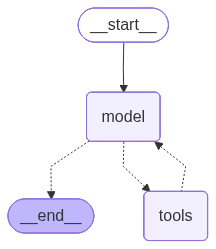

In [9]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [10]:
response = agent_executor.invoke({"messages": [("user", "Who is the current Ravens QB?")]})

print(response['messages'][-1].content)

The Ravens’ current starting quarterback is **Lamar Jackson**.


In [11]:
response

{'messages': [HumanMessage(content='Who is the current Ravens QB?', additional_kwargs={}, response_metadata={}, id='0522fbb1-9315-4363-a2bc-22bae2ce2309'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 168, 'total_tokens': 193, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DcY1WDDlHveM9qq7PtptzNFBejyEF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dfdcd-e4d8-72b3-94cf-bc3c68c16545-0', tool_calls=[{'name': 'Search', 'args': {'__arg1': 'current Baltimore Ravens quarterback 2026 season'}, 'id': 'call_a5yHIDnN5sFM8gwpXoZ26cXQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

In [12]:
for message in response['messages']:
    print(f"\n{message.__class__.__name__}:")
    if hasattr(message, 'content') and message.content:
        print(f"  Content: {message.content}")
    if hasattr(message, 'tool_calls') and message.tool_calls:
        print(f"  Tool Calls: {message.tool_calls}")


HumanMessage:
  Content: Who is the current Ravens QB?

AIMessage:
  Tool Calls: [{'name': 'Search', 'args': {'__arg1': 'current Baltimore Ravens quarterback 2026 season'}, 'id': 'call_a5yHIDnN5sFM8gwpXoZ26cXQ', 'type': 'tool_call'}]

ToolMessage:
  Content: ['The Ravens have added veteran competition for the No. 3 quarterback spot with the signing of Skylar Thompson, the team announced Monday.', 'The Baltimore Ravens are signing quarterback Skylar Thompson, his agency, SportsTrust, confirmed. The move leaves the Ravens with five ...', 'Current roster. edit. Baltimore Ravens roster. v · t · e · Quarterbacks (QB). 12 Joe Fagnano; 5 Tyler Huntley; 8 Lamar Jackson; 17 Diego Pavia; 19 Skylar ...', 'Baltimore adds QB Skylar Thompson after his 2025 season was lost to injury, giving the Ravens added depth and experience under center.', "According to NFL Network's Ian Rapoport, the Ravens have signed veteran quarterback Skylar Thompson. Rapoport expects the team to carry five ...", "Ravens Qu

# Giving Our Agent Short Term Memory

In [13]:
from langgraph.graph import MessagesState, END, StateGraph, START
from langchain_core.messages import HumanMessage, AIMessage


In [14]:
agent_executor.invoke({"messages": [("user", "Hi I am Sinan")]})['messages'][-1].content

'Hi Sinan — nice to meet you. How can I help?'

In [15]:
agent_executor.invoke({"messages": [("user", "What is my name?")]})['messages'][-1].content

'I don’t know your name unless you tell me.'

In [17]:
from langgraph.checkpoint.memory import MemorySaver  # built in short term memory

In [18]:
llm = ChatOpenAI(model="gpt-5.4-mini")
short_term_memory_agent_executor = create_agent(
    llm, tools, system_prompt=f'Today is {today}',
    checkpointer=MemorySaver()
)

In [19]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="Hi I am Sinan")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

'Hi Sinan — nice to meet you! How can I help today?'

In [20]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

'Your name is Sinan.'

In [21]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_2"}}
)['messages'][-1].content

'I don’t know your name unless you tell me.'